In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
df=pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [38]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


day moth anmd year are unncessary

In [39]:
df=df.drop(['day','month','year'],axis=1)

In [40]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [41]:
df.Classes.value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [42]:
#here we got differet spacings problems
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [43]:
df.Classes.value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

#NOW L;ETS TRY TO AMKE INDPEENDENT AND DEPENDENT FEATURES

In [44]:
X=df.drop(['FWI','Classes'],axis=1)
y=df['Classes']

In [45]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0
...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,1


In [46]:
y

0      0
1      0
2      0
3      0
4      0
      ..
238    1
239    0
240    0
241    0
242    0
Name: Classes, Length: 243, dtype: int64

now lets do standardization to make the input fetaures to scale similary

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [48]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Region
97,29,74,19,0.1,75.8,3.6,32.2,2.1,5.6,0
141,31,72,14,0.2,60.2,3.8,8.0,0.8,3.7,1
192,40,31,15,0.0,94.2,22.5,46.3,16.6,22.4,1
68,32,60,18,0.3,77.1,11.3,47.0,2.2,14.1,0
119,32,47,14,0.7,77.5,7.1,8.8,1.8,6.8,0
...,...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,7.3,0.2,1.4,0
14,28,80,17,3.1,49.4,3.0,7.4,0.4,3.0,0
92,25,76,17,7.2,46.0,1.3,7.5,0.2,1.8,0
179,34,59,16,0.0,88.1,19.5,47.2,7.4,19.5,1


In [49]:
X_test

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Region
24,31,64,15,0.0,86.7,14.2,63.8,5.7,18.3,0
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,0
152,28,58,18,2.2,63.7,3.2,8.5,1.2,3.3,1
232,34,58,13,0.2,79.5,18.7,88.0,2.1,24.4,1
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1
...,...,...,...,...,...,...,...,...,...,...
162,34,56,15,2.9,74.8,7.1,9.5,1.6,6.8,1
178,33,57,16,0.0,87.5,15.7,37.6,6.7,15.7,1
224,31,72,14,0.0,84.2,8.3,25.2,3.8,9.1,1
230,36,33,13,0.1,90.6,25.8,77.8,9.0,28.2,1


without scaling

<Axes: >

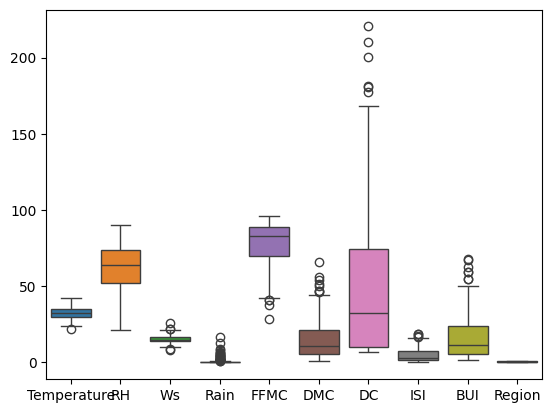

In [50]:
sns.boxplot(X_train)

Now let sdo some feature slection

In [52]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

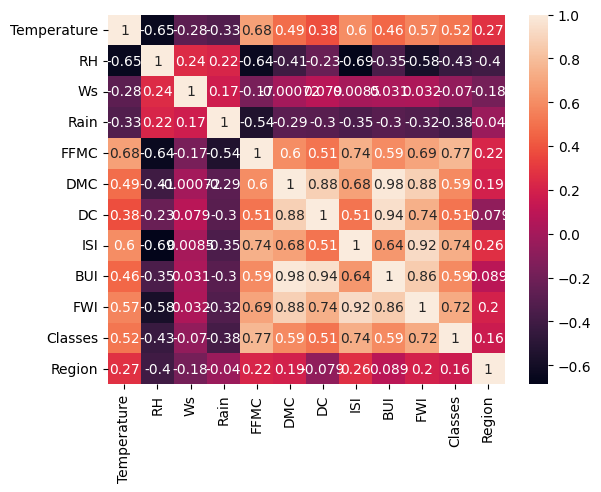

In [53]:
sns.heatmap(df.corr(),annot=True)

whart we can do now is that we acn drop those input features features taht have hogher correlation with each otehr we drop one of them 

In [57]:
def correlation(dataset,threshold):
    corr_Set=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                col_name=corr_matrix.columns[i]
                corr_Set.add(col_name)
    return corr_Set

In [58]:
corr_features=correlation(X_train,0.85)

In [59]:
corr_features

{'BUI', 'DC'}

In [61]:
X_train=X_train.drop(corr_features,axis=1)

In [62]:
X_test=X_test.drop(corr_features,axis=1)

In [63]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Region
97,29,74,19,0.1,75.8,3.6,2.1,0
141,31,72,14,0.2,60.2,3.8,0.8,1
192,40,31,15,0.0,94.2,22.5,16.6,1
68,32,60,18,0.3,77.1,11.3,2.2,0
119,32,47,14,0.7,77.5,7.1,1.8,0
...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,0
14,28,80,17,3.1,49.4,3.0,0.4,0
92,25,76,17,7.2,46.0,1.3,0.2,0
179,34,59,16,0.0,88.1,19.5,7.4,1


In [64]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

<Axes: >

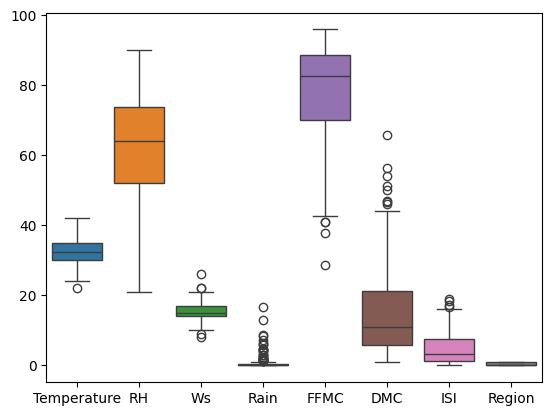

In [65]:
sns.boxplot(X_train)

<Axes: >

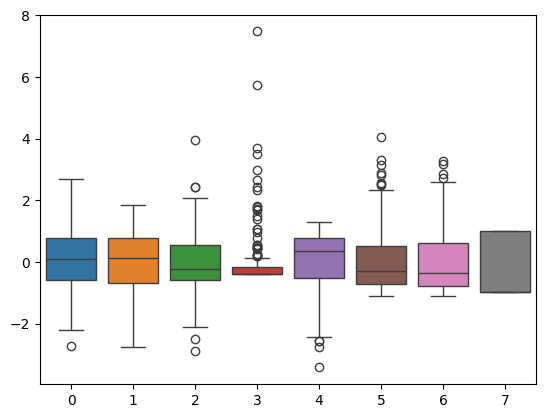

In [66]:
sns.boxplot(X_train_scaled)

now lets fit our model

In [70]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
ypred=model.predict(X_test_scaled)

In [72]:
ypred

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [73]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,ypred))
print(classification_report(y_test,ypred))

0.9672131147540983
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.97      0.97      0.97        37

    accuracy                           0.97        61
   macro avg       0.97      0.97      0.97        61
weighted avg       0.97      0.97      0.97        61



In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
penalty=['l1','l2','elasticnet']
c_values=[100,10,0.1,1,0.01]
solver=['liblinear','saga','newton-cg']
params=dict(penalty=penalty,C=c_values,solver=solver)
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,cv=cv,scoring='f1')

In [80]:
grid.fit(X_train_scaled,y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [81]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [83]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.97      1.00      0.99        37

    accuracy                           0.98        61
   macro avg       0.99      0.98      0.98        61
weighted avg       0.98      0.98      0.98        61



In [84]:
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [85]:
from sklearn.metrics import roc_auc_score,roc_curve

rocis basically used for defining how ell our model behaves across different thresholds

In [86]:
model_prob=best_model.predict_proba(X_test_scaled)[:,1]

In [87]:
model_prob

array([8.15329800e-01, 8.64149244e-01, 5.89138309e-02, 4.20772209e-01,
       7.38972008e-01, 2.05946628e-01, 5.80476096e-01, 7.71993690e-01,
       1.99064412e-01, 3.78046140e-01, 1.66974725e-01, 4.10387160e-01,
       8.83853065e-01, 9.40555252e-01, 9.38966689e-01, 3.48202930e-01,
       3.75747257e-02, 9.36230212e-04, 7.91563284e-01, 6.21503490e-01,
       4.73867793e-01, 3.25212602e-02, 8.50130497e-01, 3.43763470e-02,
       9.90575999e-01, 7.20585065e-01, 6.90883770e-01, 8.27928803e-01,
       4.20871781e-04, 8.97203769e-01, 6.92542996e-01, 7.79026322e-02,
       8.47469307e-01, 8.57376257e-01, 4.56036319e-01, 3.25805753e-01,
       5.04232645e-01, 6.48118285e-01, 4.89217942e-03, 4.12563161e-03,
       6.08160406e-01, 5.30889202e-01, 8.28852496e-01, 1.11111689e-03,
       9.65354488e-01, 8.04292661e-01, 7.25015894e-01, 8.48515896e-02,
       9.11998142e-01, 1.14143420e-01, 9.79491391e-01, 7.10383138e-01,
       9.75920993e-01, 9.24896825e-01, 9.40983833e-01, 7.57872392e-01,
      

In [89]:
print(roc_auc_score(y_test,model_prob))

0.9988738738738739


In [90]:
fpr,tpr,thresholds=roc_curve(y_test,model_prob)

In [91]:
fpr

array([0.        , 0.        , 0.        , 0.04166667, 0.04166667,
       1.        ])

In [92]:
tpr

array([0.        , 0.02702703, 0.97297297, 0.97297297, 1.        ,
       1.        ])

In [93]:
thresholds

array([           inf, 9.90575999e-01, 5.80476096e-01, 5.30889202e-01,
       5.04232645e-01, 4.20871781e-04])

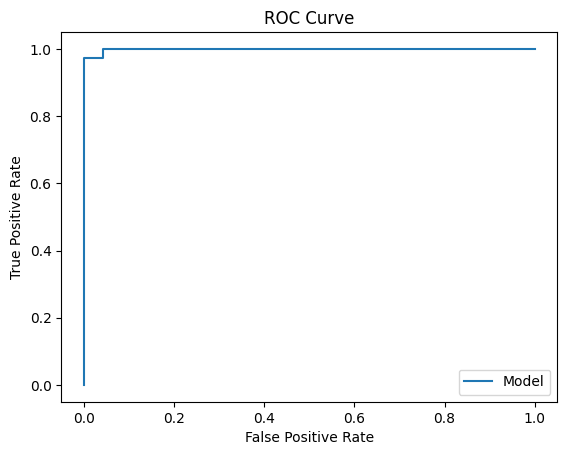

In [98]:
plt.plot(fpr, tpr, label="Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [99]:
import pickle

In [108]:
pickle.dump(best_model,open("logistic_model.pkl","wb"))
pickle.dump(scaler,open("scaler_log.pkl","wb"))


In [110]:
log_model = pickle.load(open("logistic_model.pkl","rb"))
scaler = pickle.load(open("scaler_log.pkl","rb"))

In [106]:
# scale input
X_test_scaled = scaler.transform(X_test)

# predict
predictions = log_model.predict(X_test_scaled)

In [107]:
predictions

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
X_train_scaled.

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.88272888,
        -0.62963326, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.86687565,
        -0.93058524,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  0.61540157,
         2.7271388 ,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06504105,
        -1.06948615, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.37760309,
         0.5973248 ,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -1.01748135,
        -0.86113478, -0.98907071]], shape=(182, 8))